All libraries imported successfully!

FIRST 5 ROWS:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

LAST 5 ROWS:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            

/tmp/ipykernel_5545/1352939909.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


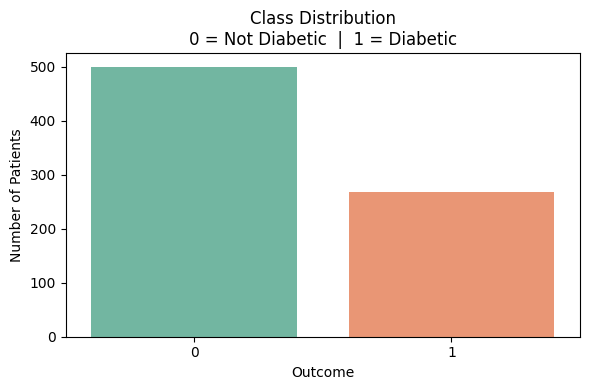

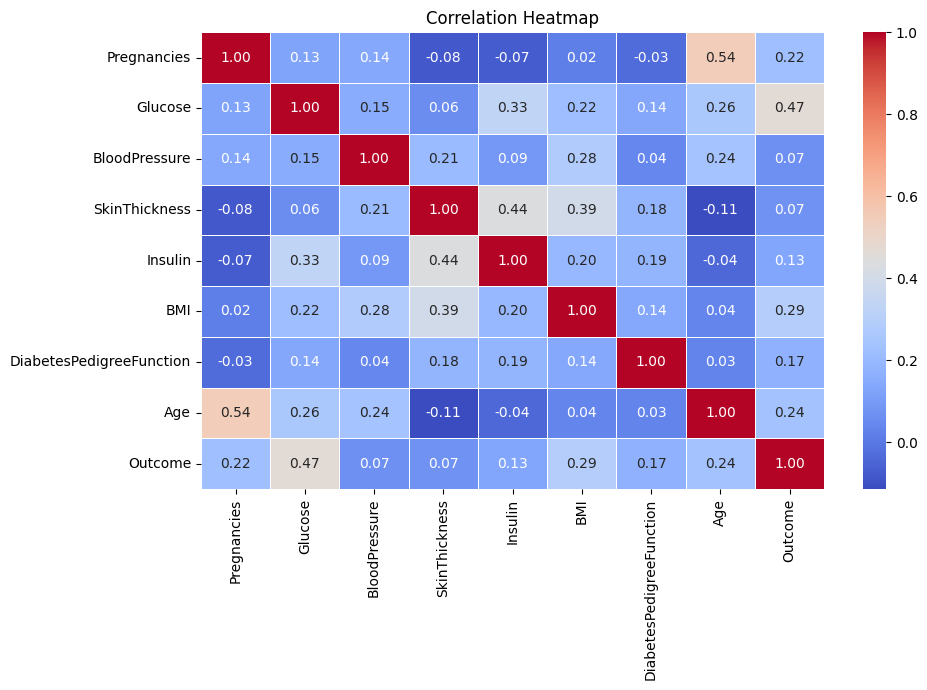

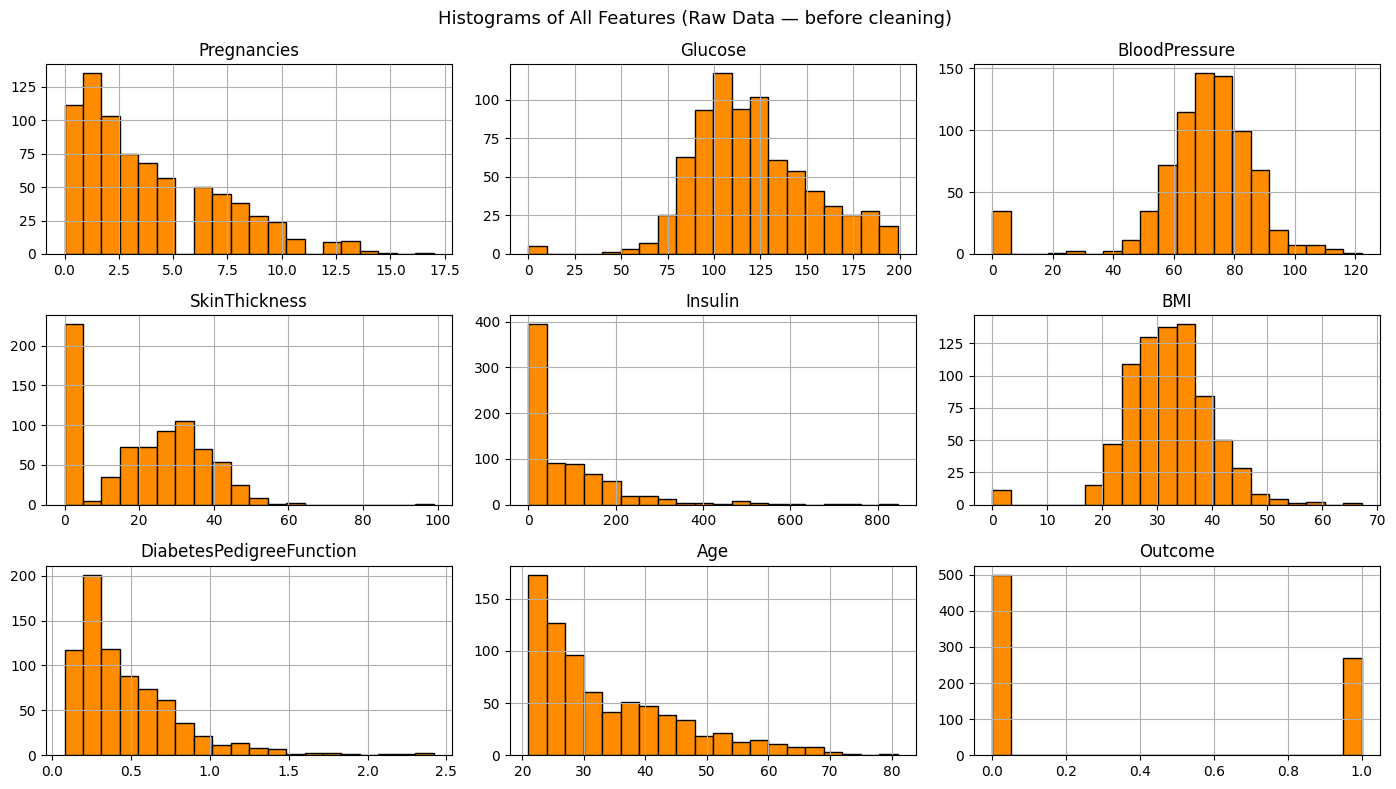

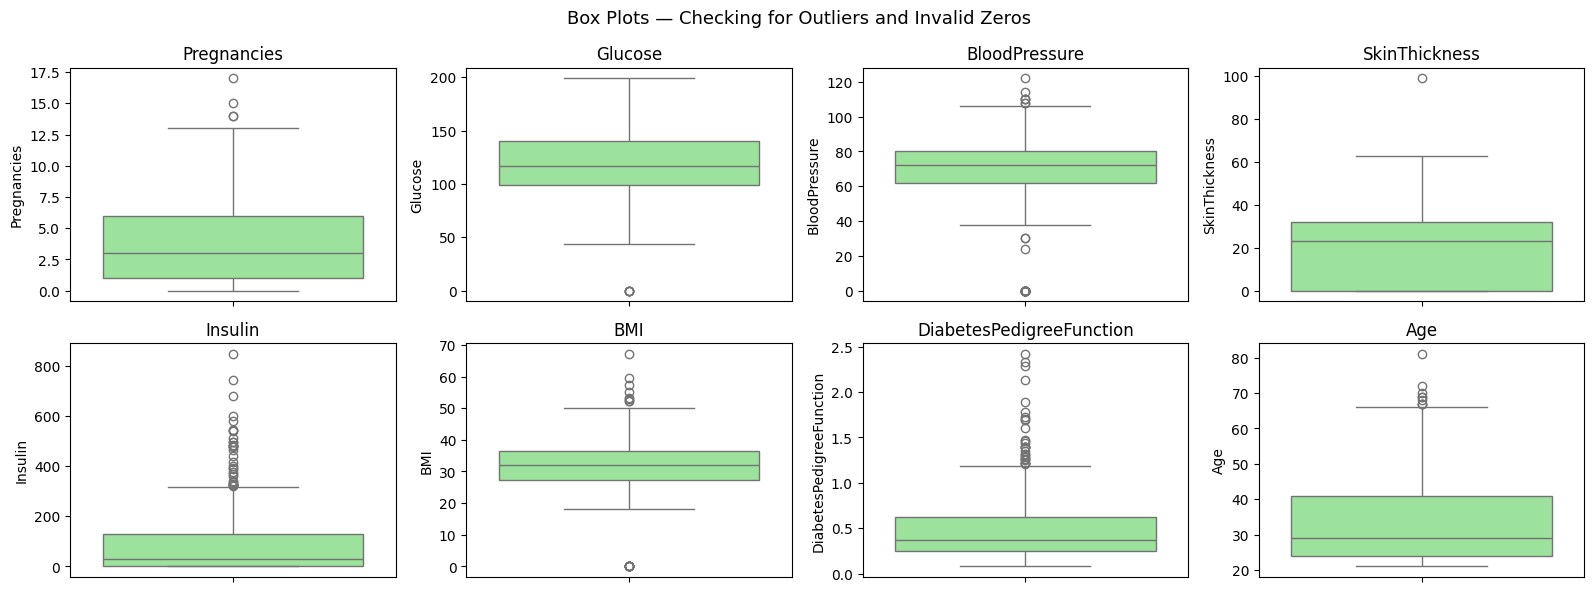

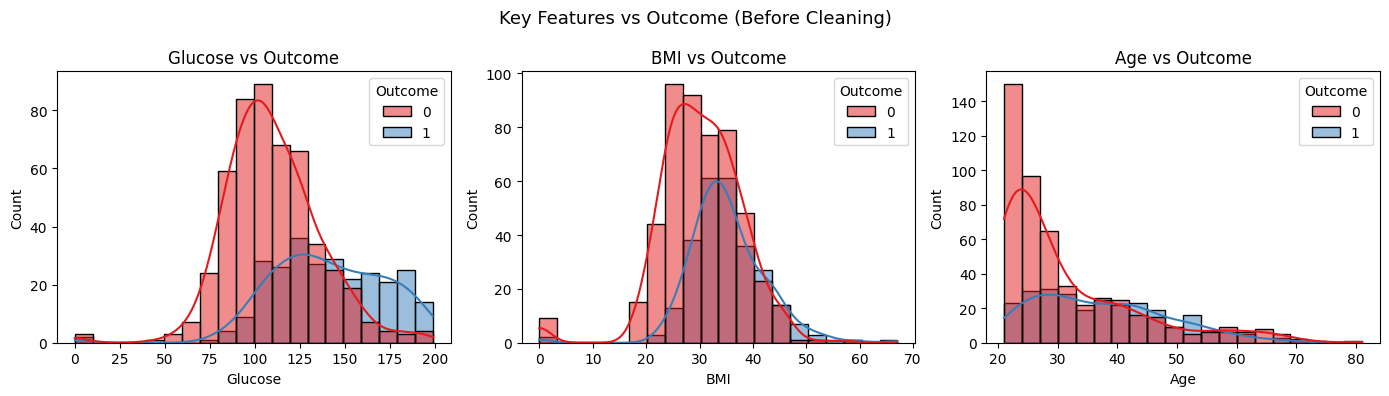

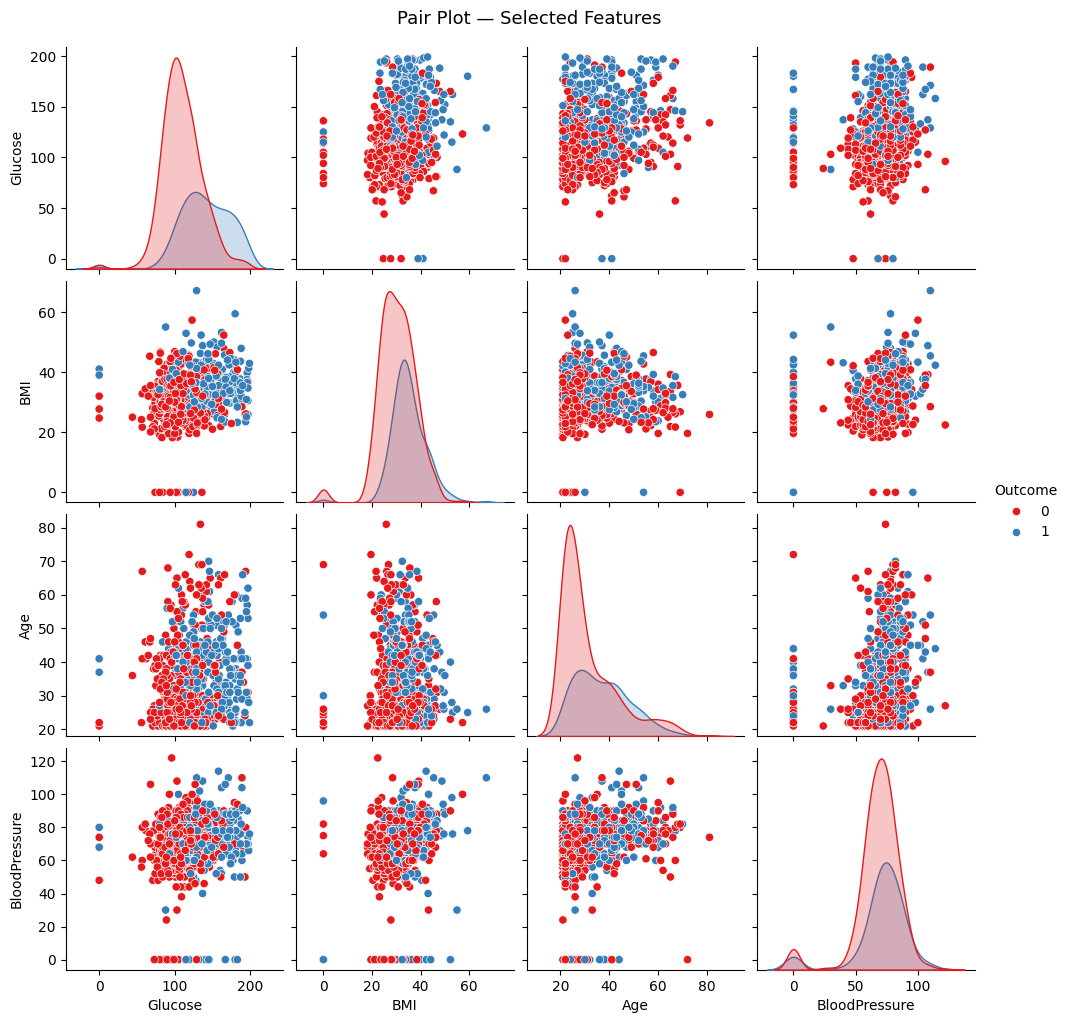


--- ZERO VALUES (Biologically Impossible) ---
  Glucose: 5 zero values found
  BloodPressure: 35 zero values found
  SkinThickness: 227 zero values found
  Insulin: 374 zero values found
  BMI: 11 zero values found

Zero values replaced with NaN (missing marker).

Duplicate rows removed: 0

Filling missing values with column median:
  Glucose: filled with median = 117.00
  BloodPressure: filled with median = 72.00
  SkinThickness: filled with median = 29.00
  Insulin: filled with median = 125.00
  BMI: filled with median = 32.30

Missing values AFTER cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset shape after cleaning: (768, 9)
Dataset is now clean and ready for modeling!

--- PREPROCESSING ---
All features are numeric. No encoding nee

/tmp/ipykernel_5545/1352939909.py:229: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


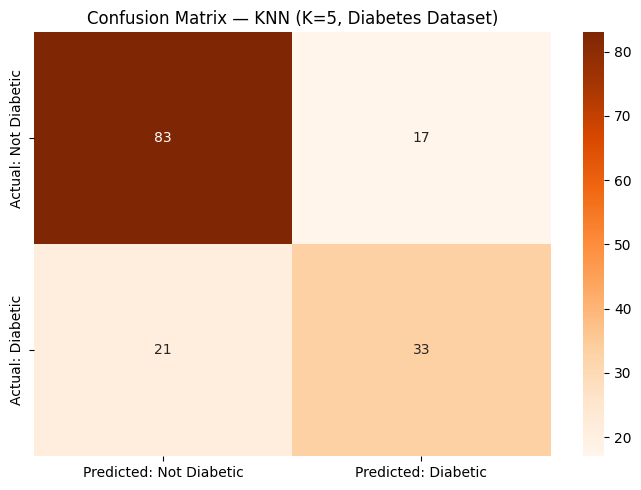


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

Not Diabetic       0.80      0.83      0.81       100
    Diabetic       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


--- CLASS PROBABILITIES (First 5 Test Samples) ---
Each prediction is a vote by K=5 nearest neighbors.

Sample 1: P(Not Diabetic)=0.4000  P(Diabetic)=0.6000  -> Predicted: Diabetic
Sample 2: P(Not Diabetic)=0.8000  P(Diabetic)=0.2000  -> Predicted: Not Diabetic
Sample 3: P(Not Diabetic)=0.8000  P(Diabetic)=0.2000  -> Predicted: Not Diabetic
Sample 4: P(Not Diabetic)=0.4000  P(Diabetic)=0.6000  -> Predicted: Diabetic
Sample 5: P(Not Diabetic)=1.0000  P(Diabetic)=0.0000  -> Predicted: Not Diabetic

--- ACCURACY FOR DIFFERENT VALUES OF K ---
  K =  1  ->  Accuracy = 72.08%
  K =  3  ->  Accuracy = 72.08%
  K =  5  ->  Accuracy = 75.32%


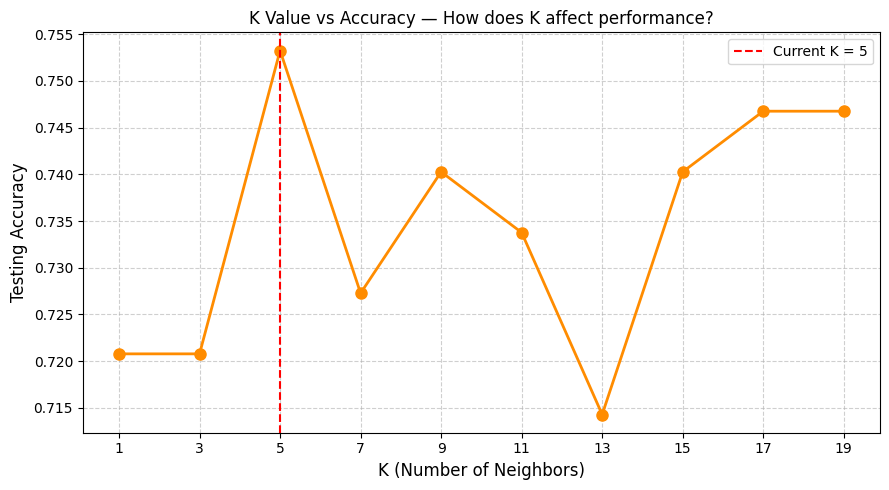


--- DECISION BOUNDARY (2 Features: Glucose vs BMI) ---
Training a separate 2-feature model just for visualization...


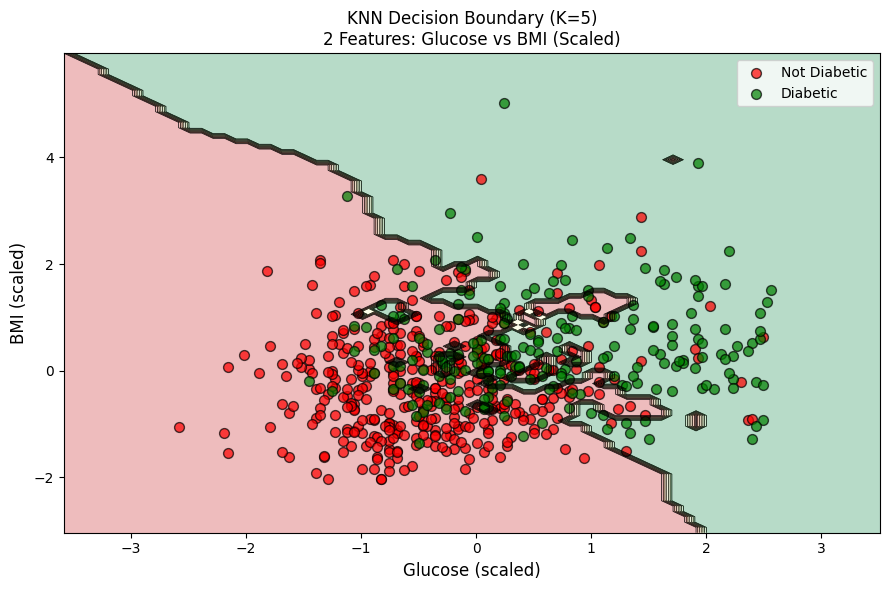

Note: This boundary is in scaled feature space.
The main model uses all 8 features and is more accurate.

                   FINAL MODEL SUMMARY
  Algorithm           : K-Nearest Neighbors (KNN)
  Dataset             : Pima Indians Diabetes (Kaggle)
  Dataset URL         : https://www.kaggle.com/datasets/
                        uciml/pima-indians-diabetes-database
  File Name           : diabetes.csv
  K (Neighbors)       : 5
  Distance Metric     : Euclidean
  Scaling Applied     : Yes (StandardScaler)
  Number of Samples   : 768
  Number of Features  : 8
  Train / Test Split  : 80% / 20%
  Training Accuracy   : 83.06%
  Testing  Accuracy   : 75.32%
  Precision           : 66.00%
  Recall              : 61.11%
  F1 Score            : 63.46%


In [ ]:
# ==============================================================
# K-NEAREST NEIGHBORS (KNN) - DIABETES PREDICTION
# ==============================================================
#
#  Dataset  : Pima Indians Diabetes Dataset
#  URL      : https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
#
#  HOW TO USE:
#  1. Open the URL above in your browser
#  2. Click "Download" to get the ZIP file
#  3. Extract it — you will find a file named  diabetes.csv
#  4. Place  diabetes.csv  in the SAME folder as this script
#  5. Run this script in VS Code or any Python IDE
#
#  COLUMNS IN diabetes.csv:
#  Pregnancies, Glucose, BloodPressure, SkinThickness,
#  Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome
#  (Outcome: 0 = Not Diabetic, 1 = Diabetic)
# ==============================================================


# ==============================================================
# STEP 1: IMPORT LIBRARIES
# ==============================================================

import pandas as pd                # For loading and working with data tables
import numpy as np                 # For numerical operations and arrays
import matplotlib.pyplot as plt    # For creating charts and graphs
import seaborn as sns              # For beautiful statistical visualizations

# Split data into training and testing sets
from sklearn.model_selection import train_test_split

# KNN classifier
from sklearn.neighbors import KNeighborsClassifier

# StandardScaler — VERY important for KNN (distance-based algorithm)
from sklearn.preprocessing import StandardScaler

# Evaluation metrics to measure model performance
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("All libraries imported successfully!")


# ==============================================================
# STEP 2: LOAD DATASET
# ==============================================================

# Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
# Make sure diabetes.csv is in the same folder as this script
df = pd.read_csv("diabetes.csv")

# Show first 5 rows
print("\n" + "=" * 55)
print("FIRST 5 ROWS:")
print(df.head())

# Show last 5 rows
print("\nLAST 5 ROWS:")
print(df.tail())

# Shape tells us how many rows (patients) and columns (features)
print("\nSHAPE (rows, columns):", df.shape)

# Names of all columns
print("\nCOLUMN NAMES:")
print(df.columns.tolist())

# Data type of each column (int, float, object)
print("\nDATA TYPES:")
print(df.dtypes)

# General dataset info
print("\nDATASET INFO:")
df.info()

# Statistical summary
# NOTE: You may notice some columns have a minimum of 0.
# For some features (Glucose, BMI, etc.) a value of 0 is biologically
# impossible — these actually represent MISSING DATA stored as zero.
# We will fix this in the Data Cleaning step.
print("\nSTATISTICAL SUMMARY:")
print(df.describe())
print("\nNOTE: Some columns show min=0 (e.g. Glucose, BMI).")
print("      These zeros are MISSING values, not actual zeros.")
print("      This will be fixed in Step 4: Data Cleaning.")


# ==============================================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================

# ----- 3.1 Check for Missing Values -----
# The dataset has no NaN yet — missing data is stored as 0
# We detect these zero-as-missing in Step 4
print("\n--- MISSING VALUES (NaN) ---")
print(df.isnull().sum())
print("(Actual missing values are stored as 0 in some columns — handled in Step 4)")

# ----- 3.2 Check for Duplicate Rows -----
print("\n--- DUPLICATE ROWS ---")
print("Total duplicate rows:", df.duplicated().sum())

# ----- 3.3 Class Distribution -----
print("\n--- CLASS DISTRIBUTION ---")
print(df['Outcome'].value_counts())
print("0 = Not Diabetic | 1 = Diabetic")

# Visualize class counts
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title("Class Distribution\n0 = Not Diabetic  |  1 = Diabetic")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

# ----- 3.4 Correlation Heatmap -----
# Shows how strongly each pair of features is related
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ----- 3.5 Histograms -----
# You will notice peaks at 0 for some columns — those are the invalid zeros
df.hist(figsize=(14, 8), bins=20, color='darkorange', edgecolor='black')
plt.suptitle("Histograms of All Features (Raw Data — before cleaning)", fontsize=13)
plt.tight_layout()
plt.show()

# ----- 3.6 Box Plots -----
# Outliers and the biologically impossible zero values will be visible
all_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

plt.figure(figsize=(16, 6))
for i, col in enumerate(all_features):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(col)
plt.suptitle("Box Plots — Checking for Outliers and Invalid Zeros", fontsize=13)
plt.tight_layout()
plt.show()

# ----- 3.7 Key Features vs Outcome (Distribution Plot) -----
# Glucose, BMI, and Age are the most important features for diabetes
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True,
             palette='Set1', bins=20)
plt.title("Glucose vs Outcome")

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='BMI', hue='Outcome', kde=True,
             palette='Set1', bins=20)
plt.title("BMI vs Outcome")

plt.subplot(1, 3, 3)
sns.histplot(data=df, x='Age', hue='Outcome', kde=True,
             palette='Set1', bins=20)
plt.title("Age vs Outcome")

plt.suptitle("Key Features vs Outcome (Before Cleaning)", fontsize=13)
plt.tight_layout()
plt.show()

# ----- 3.8 Pair Plot (Selected Features) -----
# Using only 5 features to keep the pair plot readable
pair_cols = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Outcome']
sns.pairplot(df[pair_cols], hue='Outcome', palette='Set1', diag_kind='kde')
plt.suptitle("Pair Plot — Selected Features", y=1.02, fontsize=13)
plt.show()


# ==============================================================
# STEP 4: DATA CLEANING
# ==============================================================

# ----- 4.1 Identify Biologically Impossible Zero Values -----
# In this dataset, the following columns CANNOT have a value of 0:
#   - Glucose        : A person with 0 blood glucose is dead
#   - BloodPressure  : 0 blood pressure means no heartbeat
#   - SkinThickness  : 0 skin fold thickness is not physically possible
#   - Insulin        : 0 might occur rarely, but is mostly a missing value
#   - BMI            : A BMI of 0 is impossible
#
# These zeros represent MISSING DATA, so we will:
# Step 1: Replace 0 with NaN (the proper missing value marker)
# Step 2: Fill NaN with the column MEDIAN (not mean, to avoid outlier effect)

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\n--- ZERO VALUES (Biologically Impossible) ---")
for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    print(f"  {col}: {zero_count} zero values found")

# Replace zeros with NaN in those columns
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)

print("\nZero values replaced with NaN (missing marker).")

# ----- 4.2 Remove Duplicate Rows -----
rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]
print(f"\nDuplicate rows removed: {rows_before - rows_after}")

# ----- 4.3 Fill Missing Values with Column Median -----
# We use MEDIAN instead of MEAN because:
#   - The Insulin column has very large outliers (up to 846)
#   - Mean would be pulled up by these extreme values
#   - Median is more robust to outliers

print("\nFilling missing values with column median:")
for col in zero_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"  {col}: filled with median = {median_val:.2f}")

# Verify that no missing values remain
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())
print(f"\nDataset shape after cleaning: {df.shape}")
print("Dataset is now clean and ready for modeling!")


# ==============================================================
# STEP 5: FEATURE ENGINEERING / PREPROCESSING
# ==============================================================

# WHY KNN NEEDS FEATURE SCALING (StandardScaler):
# ------------------------------------------------
# KNN is a DISTANCE-based algorithm.
# To find the K nearest neighbors, it calculates the EUCLIDEAN DISTANCE:
#   d = sqrt((x1-x2)^2 + (y1-y2)^2 + ...)
#
# PROBLEM:
# Glucose ranges from about 44 to 199 (large values)
# Pregnancies ranges from 0 to 17 (small values)
#
# In the distance formula, Glucose will DOMINATE because its
# values are much larger. The model will almost ignore Pregnancies.
# This gives us a WRONG and BIASED model.
#
# SOLUTION: StandardScaler
# It transforms every feature so that:
#   Mean = 0
#   Standard Deviation = 1
#
# After scaling, ALL features contribute EQUALLY to the distance.
#
# IMPORTANT RULE — Fit on TRAIN, Transform BOTH:
# We call scaler.fit_transform() ONLY on X_train.
# We call scaler.transform() ONLY on X_test (no fitting!).
# If we fit on X_test, the model would "peek" at test data during training.
# This is called DATA LEAKAGE and gives falsely high accuracy.

print("\n--- PREPROCESSING ---")
print("All features are numeric. No encoding needed.")
print("StandardScaler WILL be applied after train-test split.")
print("(Scaling prevents Glucose from dominating distance calculations)")


# ==============================================================
# STEP 6: FEATURE SELECTION
# ==============================================================

# X = all columns EXCEPT 'Outcome' — these are INPUT FEATURES
X = df.drop('Outcome', axis=1)

# y = the 'Outcome' column — this is what we want to PREDICT
y = df['Outcome']

print("\n--- FEATURE SELECTION ---")
print("Input Features (X):", X.columns.tolist())
print("Target Column (y)  : 'Outcome'")
print("Target Values      : 0 = Not Diabetic, 1 = Diabetic")
print("X shape:", X.shape)
print("y shape:", y.shape)


# ==============================================================
# STEP 7: TRAIN-TEST SPLIT + SCALING
# ==============================================================

# Split 80% for training, 20% for testing
# stratify=y ensures both classes are proportionally represented
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# X_train : Features used to TRAIN the model
# X_test  : Features used to TEST the model (model never saw these)
# y_train : Correct labels for training data
# y_test  : Correct labels for test data (to measure accuracy)

print("\n--- TRAIN-TEST SPLIT ---")
print("X_train:", X_train.shape, "-> 80% data used to train")
print("X_test :", X_test.shape,  "-> 20% data used to test")

# ----- Apply StandardScaler AFTER the split (to avoid data leakage) -----
scaler = StandardScaler()

# fit_transform on train: learns mean/std FROM train, then scales train
X_train_scaled = scaler.fit_transform(X_train)

# transform on test: uses the SAME mean/std from train, just scales test
X_test_scaled = scaler.transform(X_test)

print("\nStandardScaler applied:")
print("  X_train -> fit + transform (scaler learns mean/std from here)")
print("  X_test  -> transform only  (no data leakage — test info not used)")


# ==============================================================
# STEP 8: ALGORITHM EXPLANATION - KNN
# ==============================================================

# ---------------------------------------------------------------
# WHAT IS K-NEAREST NEIGHBORS (KNN)?
# ---------------------------------------------------------------
# KNN is a very simple and intuitive classification algorithm.
#
# HOW IT WORKS:
# To predict the class of a new (unknown) patient:
# 1. Calculate the DISTANCE from the new point to ALL training points
# 2. Find the K CLOSEST training points (the "neighbors")
# 3. Take a MAJORITY VOTE among those K neighbors
# 4. Predict the class with the most votes
#
# SIMPLE EXAMPLE (K=5):
# New patient's data is entered.
# KNN finds the 5 most similar patients in training data.
# Result: 4 are diabetic, 1 is not diabetic.
# Majority vote -> Prediction: DIABETIC
#
# WHAT IS K?
# K is how many neighbors we look at.
# - K = 1: Model looks at only 1 nearest neighbor. Very sensitive,
#           may overfit (memorizes training data too well).
# - K = 5: Looks at 5 neighbors. More stable and reliable.
# - K = 20: Very smooth but may miss local patterns (underfit).
# - Common choice: try odd values of K (3, 5, 7, 9...) to avoid ties.
#
# DISTANCE CALCULATION (Euclidean Distance):
# d = sqrt((x1-x2)^2 + (y1-y2)^2 + (z1-z2)^2 + ...)
# This is the straight-line distance between two points in space.
#
# WHY SCALING IS CRITICAL FOR KNN:
# Without scaling, features with large values (like Glucose: 44-199)
# dominate the distance formula and features with small values
# (like Pregnancies: 0-17) are almost ignored.
# StandardScaler fixes this by putting all features on the same scale.
#
# LAZY LEARNER:
# KNN is called a LAZY LEARNER because it does NOT build a model.
# During training, it just STORES all the data.
# All the hard work (distance calculations) happens at PREDICTION time.
# Fast to "train", slow to "predict" on very large datasets.
#
# ADVANTAGES:
# + Simple to understand
# + No assumptions about data distribution
# + Works with any number of classes
# DISADVANTAGES:
# - Slow for large datasets (calculates distance to every training point)
# - Sensitive to irrelevant features
# - REQUIRES feature scaling
# ---------------------------------------------------------------

print("\nKNN algorithm selected. K=5 will be used.")
print("See code comments above for full explanation.")


# ==============================================================
# STEP 9: TRAIN THE MODEL
# ==============================================================

# Choose the number of neighbors
K = 5

# Create KNN model
# n_neighbors : how many nearest neighbors to consider (K)
# metric      : how to measure distance (euclidean = straight-line distance)
model = KNeighborsClassifier(n_neighbors=K, metric='euclidean')

# "Train" (fit) the model
# KNN does NOT really train — it just stores all training data in memory
# All computation happens when predict() is called
model.fit(X_train_scaled, y_train)

print(f"\nKNN model created with K = {K}")
print("'Training' complete! (KNN memorized all training samples)")


# ==============================================================
# STEP 10: PREDICTIONS
# ==============================================================

# Predict class labels for all test samples
# IMPORTANT: Use X_test_scaled (not raw X_test) because model was
# trained on scaled data
y_pred = model.predict(X_test_scaled)

# Show first 10 predictions side by side with actual values
print("\n--- PREDICTIONS ON TEST DATA (First 10 Samples) ---")
print("Predicted:", list(y_pred[:10]))
print("Actual:   ", list(y_test.values[:10]))

print("\nSide-by-side comparison:")
for i in range(10):
    pred_label   = "Diabetic    " if y_pred[i] == 1 else "Not Diabetic"
    actual_label = "Diabetic    " if y_test.values[i] == 1 else "Not Diabetic"
    correct      = "CORRECT" if y_pred[i] == y_test.values[i] else "WRONG"
    print(f"  Sample {i+1}: Predicted={pred_label} | Actual={actual_label} -> {correct}")

# ----- Predict a custom single patient -----
# Feature order must match the training columns:
# Pregnancies, Glucose, BloodPressure, SkinThickness,
# Insulin, BMI, DiabetesPedigreeFunction, Age
custom_patient = [[6, 148, 72, 35, 0, 33.6, 0.627, 50]]

# Scale the custom patient using the SAME scaler (already fitted on X_train)
# We must scale it because the model was trained on scaled data
custom_patient_scaled = scaler.transform(custom_patient)

custom_pred  = model.predict(custom_patient_scaled)
custom_proba = model.predict_proba(custom_patient_scaled)

print("\n--- CUSTOM PATIENT PREDICTION ---")
print("Feature Order: Pregnancies, Glucose, BloodPressure, SkinThickness,")
print("               Insulin, BMI, DiabetesPedigreeFunction, Age")
print("Input Values :", custom_patient[0])
print("Prediction   :", "Diabetic (1)" if custom_pred[0] == 1 else "Not Diabetic (0)")
print(f"Probability - Not Diabetic : {custom_proba[0][0] * 100:.2f}%")
print(f"Probability - Diabetic     : {custom_proba[0][1] * 100:.2f}%")
print(f"(These probabilities = fraction of K={K} neighbors in each class)")


# ==============================================================
# STEP 11: EVALUATION
# ==============================================================

# Calculate all evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\n--- EVALUATION METRICS ---")
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"            How many predictions were correct overall")
print(f"\nPrecision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"            Of all predicted 'Diabetic', how many are truly Diabetic")
print(f"\nRecall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"            Of all actual 'Diabetic' cases, how many did we catch")
print(f"\nF1 Score  : {f1:.4f}  ({f1*100:.2f}%)")
print(f"            Harmonic mean of Precision and Recall")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n--- CONFUSION MATRIX ---")
print(cm)
print(f"\nTrue Negatives  (TN): {cm[0][0]}  -> Correctly predicted Not Diabetic")
print(f"False Positives (FP): {cm[0][1]}  -> Wrongly predicted Diabetic (actually Not Diabetic)")
print(f"False Negatives (FN): {cm[1][0]}  -> Wrongly predicted Not Diabetic (actually Diabetic)")
print(f"True Positives  (TP): {cm[1][1]}  -> Correctly predicted Diabetic")

# Display confusion matrix as a heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted: Not Diabetic', 'Predicted: Diabetic'],
            yticklabels=['Actual: Not Diabetic',    'Actual: Diabetic'])
plt.title(f"Confusion Matrix — KNN (K={K}, Diabetes Dataset)")
plt.tight_layout()
plt.show()

# Full classification report
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Not Diabetic', 'Diabetic']))


# ==============================================================
# STEP 12: FEATURE IMPORTANCE / INTERPRETATION
# ==============================================================

# NOTE: KNN does NOT support feature importance.
# KNN is a LAZY LEARNER — it builds no model and has no weights,
# coefficients, or feature scores. All it does is measure distances.
# Therefore, there is NO direct way to rank features by importance.
#
# Alternative interpretations we CAN do:
#  1. predict_proba() — shows the fraction of K neighbors per class
#  2. K value vs Accuracy — helps choose the best K

# Show class probabilities for first 5 test samples
proba_test = model.predict_proba(X_test_scaled[:5])

print("\n--- CLASS PROBABILITIES (First 5 Test Samples) ---")
print(f"Each prediction is a vote by K={K} nearest neighbors.\n")
for i in range(5):
    label = "Diabetic" if y_pred[i] == 1 else "Not Diabetic"
    print(f"Sample {i+1}: P(Not Diabetic)={proba_test[i][0]:.4f}  "
          f"P(Diabetic)={proba_test[i][1]:.4f}  -> Predicted: {label}")

# ----- K Value vs Accuracy Chart -----
# Try multiple odd values of K and see which gives the best accuracy
print("\n--- ACCURACY FOR DIFFERENT VALUES OF K ---")
k_values   = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
accuracies = []

for k_val in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k_val, metric='euclidean')
    knn_temp.fit(X_train_scaled, y_train)
    pred_temp = knn_temp.predict(X_test_scaled)
    acc_temp  = accuracy_score(y_test, pred_temp)
    accuracies.append(acc_temp)
    print(f"  K = {k_val:2d}  ->  Accuracy = {acc_temp * 100:.2f}%")

# Plot K vs Accuracy
plt.figure(figsize=(9, 5))
plt.plot(k_values, accuracies, marker='o', color='darkorange',
         linewidth=2, markersize=8)
plt.axvline(x=K, color='red', linestyle='--', label=f'Current K = {K}')
plt.xlabel("K (Number of Neighbors)", fontsize=12)
plt.ylabel("Testing Accuracy", fontsize=12)
plt.title("K Value vs Accuracy — How does K affect performance?", fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# ==============================================================
# STEP 13: DECISION BOUNDARY (2 Features)
# ==============================================================

# We cannot draw a decision boundary with 8 features at once.
# We select 2 of the most important features for diabetes:
#   - 'Glucose' (blood glucose level — strongest predictor)
#   - 'BMI'     (body mass index — strong predictor)
#
# NOTE: This 2-feature model is only for VISUALIZATION.
#       The main model above uses all 8 features.
# NOTE: The decision boundary is shown in SCALED feature space.

print("\n--- DECISION BOUNDARY (2 Features: Glucose vs BMI) ---")
print("Training a separate 2-feature model just for visualization...")

# Extract 2 features
X_2d = df[['Glucose', 'BMI']].values
y_2d = df['Outcome'].values

# Split the 2-feature data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42
)

# Scale the 2-feature data (critical for KNN)
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled  = scaler_2d.transform(X_test_2d)

# Train KNN on these 2 scaled features
model_2d = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
model_2d.fit(X_train_2d_scaled, y_train_2d)

# Create a fine grid over the scaled feature space
h     = 0.1
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1
y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Predict class for every point in the grid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary with actual data points
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.contour(xx, yy, Z, colors='black', linewidths=0.5)

for cls, label, color in [(0, 'Not Diabetic', 'red'), (1, 'Diabetic', 'green')]:
    mask = y_train_2d == cls
    plt.scatter(X_train_2d_scaled[mask, 0], X_train_2d_scaled[mask, 1],
                c=color, label=label,
                edgecolors='black', s=50, alpha=0.7)

plt.xlabel("Glucose (scaled)", fontsize=12)
plt.ylabel("BMI (scaled)", fontsize=12)
plt.title(f"KNN Decision Boundary (K=5)\n2 Features: Glucose vs BMI (Scaled)")
plt.legend()
plt.tight_layout()
plt.show()

print("Note: This boundary is in scaled feature space.")
print("The main model uses all 8 features and is more accurate.")


# ==============================================================
# STEP 14: FINAL SUMMARY
# ==============================================================

# Training accuracy (on scaled training data)
train_pred     = model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, train_pred)

print("\n" + "=" * 60)
print("                   FINAL MODEL SUMMARY")
print("=" * 60)
print(f"  Algorithm           : K-Nearest Neighbors (KNN)")
print(f"  Dataset             : Pima Indians Diabetes (Kaggle)")
print(f"  Dataset URL         : https://www.kaggle.com/datasets/")
print(f"                        uciml/pima-indians-diabetes-database")
print(f"  File Name           : diabetes.csv")
print(f"  K (Neighbors)       : {K}")
print(f"  Distance Metric     : Euclidean")
print(f"  Scaling Applied     : Yes (StandardScaler)")
print(f"  Number of Samples   : {X.shape[0]}")
print(f"  Number of Features  : {X.shape[1]}")
print(f"  Train / Test Split  : 80% / 20%")
print(f"  Training Accuracy   : {train_accuracy * 100:.2f}%")
print(f"  Testing  Accuracy   : {accuracy * 100:.2f}%")
print(f"  Precision           : {precision * 100:.2f}%")
print(f"  Recall              : {recall * 100:.2f}%")
print(f"  F1 Score            : {f1 * 100:.2f}%")
print("=" * 60)